# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: SOTA ARCHITECTURE + BALANCED ROOT SCALING on: cuda
⏳ Loading Data...
✅ Data Loaded. Numerics: 40, Categoricals: 3

--- PHASE A: META-GENERATION ---
   Generating NCA Targets...
   Generating IsoForest Targets...

--- PHASE 1: PRETRAINING (DINO + iBOT) ---
DINO Epoch 1 | Loss: 7.3708
DINO Epoch 2 | Loss: 7.1942
DINO Epoch 3 | Loss: 6.7561
DINO Epoch 4 | Loss: 6.4555
DINO Epoch 5 | Loss: 6.1998
DINO Epoch 6 | Loss: 6.0737
DINO Epoch 7 | Loss: 6.0117
DINO Epoch 8 | Loss: 5.9365
DINO Epoch 9 | Loss: 5.8655
DINO Epoch 10 | Loss: 5.7855

--- PHASE 2: PROXY ANCHOR FINE-TUNING ---
ProxyFT Epoch 1 | Loss: 26.7641
ProxyFT Epoch 2 | Loss: 8.5461
ProxyFT Epoch 3 | Loss: 5.6472
ProxyFT Epoch 4 | Loss: 4.5505
ProxyFT Epoch 5 | Loss: 3.9938
ProxyFT Epoch 6 | Loss: 3.5708
ProxyFT Epoch 7 | Loss: 3.2339
ProxyFT Epoch 8 | Loss: 2.8517
ProxyFT Epoch 9 | Loss: 2.7764
ProxyFT Epoch 10 | Loss: 2.6058

--- PHASE 3: BALANCED TRAINING (ROOT SCALING) ---
⚖️ Balanced Class Weights: [ 0.740666    0.61

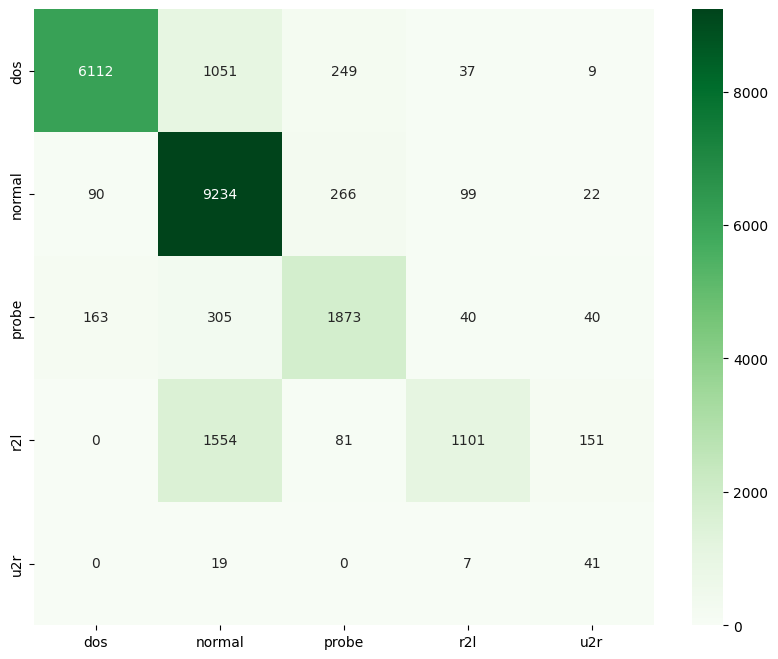

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler_amp = torch.cuda.amp.GradScaler()
print(f"🚀 PIPELINE: SOTA ARCHITECTURE + BALANCED ROOT SCALING on: {device}")

# ==========================================
# 1. SOTA PREPROCESSING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

CAT_COLS = ['protocol_type', 'service', 'flag']

def process_dataframe_sota(df, is_training=True, encoders=None, scaler=None):
    if 'label' in df.columns:
        df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
        df['category'] = df['label'].map(attack_map).fillna('other')

    num_cols_to_log = ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']
    for c in num_cols_to_log:
        if c in df.columns: df[c] = np.log1p(df[c])
        
    if 'src_bytes' in df.columns and 'dst_bytes' in df.columns:
        df['byte_ratio'] = (df['src_bytes']) / (df['dst_bytes'] + 1)
    if 'srv_count' in df.columns and 'count' in df.columns:
        df['srv_diff'] = df['srv_count'] - df['count']

    exclude = CAT_COLS + ['label', 'category', 'id', 'difficulty_level']
    current_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    current_cat_cols = [c for c in CAT_COLS if c in df.columns]

    if is_training:
        scaler = StandardScaler()
        num_cols = current_num_cols
        X_num = scaler.fit_transform(df[num_cols]).astype(np.float32)
    else:
        num_cols = encoders['num_cols']
        df_aligned = pd.DataFrame(0.0, index=df.index, columns=num_cols)
        present = [c for c in current_num_cols if c in num_cols]
        df_aligned[present] = df[present]
        X_num = scaler.transform(df_aligned).astype(np.float32)

    X_cat_list = []
    
    if is_training:
        encoders_map = {}
        for col in current_cat_cols:
            uniques = df[col].unique()
            mapping = {val: i+1 for i, val in enumerate(uniques)}
            encoders_map[col] = mapping
            X_cat_list.append(df[col].map(mapping).fillna(0).values.reshape(-1, 1))
        
        X_cat = np.hstack(X_cat_list).astype(np.int64)
        vocab_sizes = {col: len(encoders_map[col]) + 1 for col in current_cat_cols}
        
        final_info = {
            'num_cols': num_cols,
            'cat_cols': current_cat_cols,
            'cat_maps': encoders_map,
            'vocab_sizes': vocab_sizes
        }
    else:
        saved_maps = encoders['cat_maps']
        target_cat_cols = encoders['cat_cols']
        for col in target_cat_cols:
            if col in df.columns:
                mapping = saved_maps.get(col, {})
                mapped = df[col].map(mapping).fillna(0).values.reshape(-1, 1)
                X_cat_list.append(mapped)
            else:
                X_cat_list.append(np.zeros((len(df), 1), dtype=np.int64))
        X_cat = np.hstack(X_cat_list).astype(np.int64)
        final_info = None

    return X_num, X_cat, df['category'] if 'category' in df.columns else None, final_info, scaler

# --- LOAD DATA ---
print("⏳ Loading Data...")
try:
    df_raw = pd.read_csv('Data/network_connections.csv')
    X_num, X_cat, y, TRAIN_INFO, scaler = process_dataframe_sota(df_raw, is_training=True)
    print(f"✅ Data Loaded. Numerics: {X_num.shape[1]}, Categoricals: {X_cat.shape[1]}")
except FileNotFoundError:
    print("⚠️ Using Dummy Data")
    dummy_data = {
        'duration': np.random.rand(2000), 'src_bytes': np.random.rand(2000)*1000,
        'dst_bytes': np.random.rand(2000)*1000,
        'protocol_type': np.random.choice(['tcp', 'udp', 'icmp'], 2000),
        'service': np.random.choice(['http', 'ftp', 'ssh', 'private'], 2000),
        'flag': np.random.choice(['SF', 'S0', 'REJ'], 2000),
        'label': np.random.choice(['normal', 'neptune', 'buffer_overflow'], 2000)
    }
    df_raw = pd.DataFrame(dummy_data)
    X_num, X_cat, y, TRAIN_INFO, scaler = process_dataframe_sota(df_raw, is_training=True)

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

indices = np.arange(len(y_vec))
idx_train, idx_test = train_test_split(indices, test_size=0.2, stratify=y_vec, random_state=42)

X_num_train = torch.tensor(X_num[idx_train], dtype=torch.float32)
X_cat_train = torch.tensor(X_cat[idx_train], dtype=torch.long)
y_train = y_vec[idx_train]

X_num_test = torch.tensor(X_num[idx_test], dtype=torch.float32)
X_cat_test = torch.tensor(X_cat[idx_test], dtype=torch.long)
y_test = y_vec[idx_test]

y_train_tensor = torch.tensor(y_train, dtype=torch.long)

del df_raw
gc.collect()

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
print("\n--- PHASE A: META-GENERATION ---")
X_train_combined = np.hstack([X_num_train.numpy(), X_cat_train.numpy()])

print("   Generating NCA Targets...")
nca = NeighborhoodComponentsAnalysis(n_components=10, random_state=42)
idx_sample = np.random.choice(len(X_train_combined), size=min(2000, len(X_train_combined)), replace=False)
nca.fit(X_train_combined[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_combined).astype(np.float32)

print("   Generating IsoForest Targets...")
idx_iso = np.random.choice(len(X_train_combined), size=min(10000, len(X_train_combined)), replace=False)
iso = IsolationForest(n_estimators=50, contamination='auto', n_jobs=-1).fit(X_train_combined[idx_iso])
X_train_iso = iso.decision_function(X_train_combined).reshape(-1, 1).astype(np.float32)

Meta_Targets = np.hstack([X_train_nca, X_train_iso])
meta_dim = Meta_Targets.shape[1]
meta_train_tensor = torch.tensor(Meta_Targets, dtype=torch.float32)

gc.collect()

# ==========================================
# 3. SOTA ARCHITECTURE (ALL CLASSES)
# ==========================================
class TabularViT_SOTA(nn.Module):
    def __init__(self, num_numeric, vocab_sizes, embed_dim=64, depth=4, num_registers=4, aux_dim=0):
        super().__init__()
        
        self.num_proj = nn.Parameter(torch.randn(num_numeric, embed_dim) / np.sqrt(embed_dim))
        self.num_bias = nn.Parameter(torch.zeros(num_numeric, embed_dim))
        
        self.cat_embeds = nn.ModuleList([
            nn.Embedding(vocab_size, embed_dim, padding_idx=0) 
            for vocab_size in vocab_sizes
        ])
        
        self.type_embed = nn.Embedding(2, embed_dim)
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.registers = nn.Parameter(torch.zeros(1, num_registers, embed_dim))
        self.mask_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        enc = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=256, 
                                         batch_first=True, norm_first=True, activation='gelu', dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc, num_layers=depth)
        
        if aux_dim > 0:
            self.aux_head = nn.Sequential(nn.Linear(embed_dim, 64), nn.ReLU(), nn.Linear(64, aux_dim))
        else: self.aux_head = None

    def forward(self, x_num, x_cat, mask=None):
        b = x_num.shape[0]
        
        e_num = x_num.unsqueeze(-1) * self.num_proj.unsqueeze(0) + self.num_bias.unsqueeze(0)
        e_num = e_num + self.type_embed(torch.tensor(0, device=x_num.device))
        
        e_cat_list = []
        for i, emb_layer in enumerate(self.cat_embeds):
            e_cat_list.append(emb_layer(x_cat[:, i]))
        e_cat = torch.stack(e_cat_list, dim=1) 
        e_cat = e_cat + self.type_embed(torch.tensor(1, device=x_num.device))
        
        x_feats = torch.cat([e_num, e_cat], dim=1)
        
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).expand_as(x_feats)
            x_feats = torch.where(mask_expanded, self.mask_token.to(x_feats.dtype), x_feats)
            
        cls_tokens = self.cls_token.expand(b, -1, -1)
        regs = self.registers.expand(b, -1, -1)
        x_seq = torch.cat((cls_tokens, regs, x_feats), dim=1)
        
        x_out = self.transformer(x_seq)
        
        cls_out = x_out[:, 0, :]
        aux_out = self.aux_head(cls_out) if self.aux_head is not None else None
        
        return cls_out, x_out[:, 1+self.registers.shape[1]:, :], aux_out

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=256, bottleneck_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)

class MIMHead(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.decoder = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, 1))
    def forward(self, x_seq): return self.decoder(x_seq).squeeze(-1)

# DEFINITION OF MLP PROBE (FIXED LOCATION)
class MLPProbe(nn.Module):
    def __init__(self, in_dim, n_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, n_cls)
        )
    def forward(self, x): return self.net(x)

# ==========================================
# 4. ROBUST NOISE COLLATOR
# ==========================================
class RobustNoiseCollator:
    def __init__(self, mask_ratio=0.5, noise_scale=0.05):
        self.mask_ratio = mask_ratio
        self.noise = noise_scale

    def __call__(self, batch):
        x_num = torch.stack([item[0] for item in batch])
        x_cat = torch.stack([item[1] for item in batch])
        y = torch.stack([item[2] for item in batch])
        meta = torch.stack([item[3] for item in batch])
        
        # 1. Dirty Jitter: Apply everywhere, including zeros
        noise = torch.randn_like(x_num) * self.noise
        x_num_aug = x_num + noise
        
        # 2. Random Masking
        batch_size, n_num = x_num.shape
        _, n_cat = x_cat.shape
        total_feats = n_num + n_cat
        mask = torch.rand((batch_size, total_feats)) < self.mask_ratio
        
        return x_num, x_cat, x_num_aug, x_cat, mask, y, meta

# ==========================================
# 5. TRAINING SETUP
# ==========================================
BATCH_SIZE = 64
GRAD_ACCUM = 4
EMBED_DIM = 64
NUM_PROTOTYPES = 1024

vocab_sizes_list = list(TRAIN_INFO['vocab_sizes'].values())
num_numeric_feats = X_num_train.shape[1]

# Models
student_enc = TabularViT_SOTA(num_numeric_feats, vocab_sizes_list, EMBED_DIM, aux_dim=meta_dim).to(device)
student_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)
student_mim = MIMHead(EMBED_DIM).to(device)

teacher_enc = TabularViT_SOTA(num_numeric_feats, vocab_sizes_list, EMBED_DIM, aux_dim=meta_dim).to(device)
teacher_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)

teacher_enc.load_state_dict(student_enc.state_dict())
teacher_dino.load_state_dict(student_dino.state_dict())
for p in teacher_enc.parameters(): p.requires_grad = False
for p in teacher_dino.parameters(): p.requires_grad = False

# Losses
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embed_dim, margin=0.1, alpha=32):
        super().__init__()
        self.num_classes = num_classes; self.margin = margin; self.alpha = alpha
        self.proxies = nn.Parameter(torch.randn(num_classes, embed_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')
    def forward(self, embeddings, labels):
        P = F.normalize(self.proxies, p=2, dim=1)
        X = F.normalize(embeddings, p=2, dim=1)
        cos_sim = torch.matmul(X, P.t())
        one_hot = torch.eye(self.num_classes, device=embeddings.device)[labels]
        pos_term = torch.exp(-self.alpha * (cos_sim - self.margin))
        pos_term = torch.where(one_hot == 1, pos_term, torch.zeros_like(pos_term))
        loss_pos = torch.log(1 + pos_term.sum(dim=0)).mean()
        neg_term = torch.exp(self.alpha * (cos_sim + self.margin))
        neg_term = torch.where(one_hot == 0, neg_term, torch.zeros_like(neg_term))
        loss_neg = torch.log(1 + neg_term.sum(dim=0)).mean()
        return loss_pos + loss_neg

class KoLeoLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, student_output, eps=1e-8):
        x = F.normalize(student_output, p=2, dim=1)
        dots = torch.mm(x, x.t())
        dots.view(-1)[::x.shape[0]+1] = -float('inf') 
        _, I = torch.max(dots, dim=1)
        return -torch.log(torch.sqrt(2 * (1 - (x * x[I]).sum(dim=1) + eps)) + eps).mean()

class SinkhornKnopp(nn.Module):
    def __init__(self, num_prototypes, epsilon=0.05, iterations=3):
        super().__init__()
        self.epsilon = epsilon; self.iterations = iterations
        self.register_buffer("queue", F.normalize(torch.randn(2048, num_prototypes), dim=1))
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))
    @torch.no_grad()
    def update_queue(self, teacher_output):
        batch_size = teacher_output.shape[0]
        ptr = int(self.queue_ptr)
        if ptr + batch_size <= 2048: self.queue[ptr:ptr+batch_size] = teacher_output
        else: self.queue[ptr:] = teacher_output[:2048-ptr]
        self.queue_ptr[0] = (ptr + batch_size) % 2048
    @torch.no_grad()
    def forward(self, teacher_output):
        full_support = torch.cat([teacher_output, self.queue.clone().detach()], dim=0).float()
        Q = torch.exp(full_support / self.epsilon).t()
        B = Q.shape[1]; K = Q.shape[0]; sum_Q = torch.sum(Q); Q /= sum_Q
        for _ in range(self.iterations):
            Q /= torch.sum(Q, dim=1, keepdim=True); Q /= K
            Q /= torch.sum(Q, dim=0, keepdim=True); Q /= B
        return (Q * B).t()[:teacher_output.shape[0]]

sinkhorn = SinkhornKnopp(NUM_PROTOTYPES).to(device)
koleo = KoLeoLoss().to(device)
optimizer = optim.AdamW(list(student_enc.parameters()) + list(student_dino.parameters()) + list(student_mim.parameters()), lr=0.001)

class_counts = np.bincount(y_train)
sample_weights = (1. / (np.log1p(class_counts) + 1e-6))[y_train]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(y_train), replacement=True)

# USE ROBUST COLLATOR
collator = RobustNoiseCollator(mask_ratio=0.5, noise_scale=0.05)

train_dl = DataLoader(TensorDataset(X_num_train, X_cat_train, y_train_tensor, meta_train_tensor), 
                      batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, 
                      collate_fn=collator, drop_last=True)

def update_teacher(m):
    with torch.no_grad():
        for ps, pt in zip(student_enc.parameters(), teacher_enc.parameters()): pt.data = pt.data * m + ps.data * (1 - m)
        for ps, pt in zip(student_dino.parameters(), teacher_dino.parameters()): pt.data = pt.data * m + ps.data * (1 - m)

# ==========================================
# PHASE 1: PRETRAINING (DINO + MIM + ROBUST)
# ==========================================
print("\n--- PHASE 1: PRETRAINING (DINO + iBOT) ---")
for epoch in range(10): 
    student_enc.train(); student_dino.train(); student_mim.train()
    loss_total = 0
    m = 0.996 + (1.0 - 0.996) * (epoch / 10)
    
    optimizer.zero_grad()
    for i, (xn_t, xc_t, xn_s, xc_s, mask, _, _) in enumerate(train_dl): 
        xn_t, xc_t = xn_t.to(device), xc_t.to(device)
        xn_s, xc_s = xn_s.to(device), xc_s.to(device)
        mask = mask.to(device)
        
        with torch.cuda.amp.autocast():
            s_cls, s_seq, _ = student_enc(xn_s, xc_s, mask=mask) 
            s_dino_out = student_dino(s_cls)
            s_rec = student_mim(s_seq) 
            
            with torch.no_grad():
                t_cls, _, _ = teacher_enc(xn_t, xc_t, mask=None)
                t_dino_out = teacher_dino(t_cls)
            
            t_targets = sinkhorn(t_dino_out)
            l_dino = -torch.sum(t_targets * F.log_softmax(s_dino_out / 0.1, dim=-1), dim=-1).mean()
            
            mask_num = mask[:, :num_numeric_feats]
            if mask_num.sum() > 0:
                l_mim = F.mse_loss(s_rec[:, :num_numeric_feats][mask_num], xn_t[mask_num])
            else:
                l_mim = torch.tensor(0.0, device=device)
            l_koleo = koleo(s_cls)
            loss = (l_dino + 0.5 * l_mim + 0.1 * l_koleo) / GRAD_ACCUM
        
        scaler_amp.scale(loss).backward()
        if (i+1) % GRAD_ACCUM == 0:
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad()
            update_teacher(m)
            sinkhorn.update_queue(t_dino_out)
        loss_total += loss.item() * GRAD_ACCUM
    print(f"DINO Epoch {epoch+1} | Loss: {loss_total/len(train_dl):.4f}")

# ==========================================
# PHASE 2: PROXY FT
# ==========================================
print("\n--- PHASE 2: PROXY ANCHOR FINE-TUNING ---")

proxy_loss_fn = ProxyAnchorLoss(num_classes, EMBED_DIM).to(device)
aux_loss_fn = nn.MSELoss()
opt_ft = optim.AdamW(list(student_enc.parameters()) + list(proxy_loss_fn.parameters()), lr=0.0001)

train_dl_ft = DataLoader(TensorDataset(X_num_train, X_cat_train, y_train_tensor, meta_train_tensor), 
                         batch_size=128, sampler=sampler, shuffle=False)

for epoch in range(10):
    student_enc.train()
    loss_acc = 0
    for xn, xc, y, meta in train_dl_ft:
        xn, xc, y, meta = xn.to(device), xc.to(device), y.to(device), meta.to(device)
        opt_ft.zero_grad()
        embeddings, _, aux_pred = student_enc(xn, xc, mask=None)
        l_proxy = proxy_loss_fn(embeddings, y)
        l_aux = aux_loss_fn(aux_pred, meta)
        loss = l_proxy + (0.5 * l_aux)
        loss.backward()
        opt_ft.step()
        loss_acc += loss.item()
    print(f"ProxyFT Epoch {epoch+1} | Loss: {loss_acc/len(train_dl_ft):.4f}")

# ==========================================
# PHASE 3: BALANCED PROBE TRAINING (DAMPED WEIGHTS)
# ==========================================
print("\n--- PHASE 3: BALANCED TRAINING (ROOT SCALING) ---")

# 1. Root Scaling Logic
raw_counts = np.bincount(y_train)
total_samples = len(y_train)
# Formula: sqrt(N_total / (N_classes * N_i)) -> Dampens extreme weights
class_weights_np = (total_samples / (num_classes * raw_counts)) ** 0.5 

# Gentle manual boost for rare classes
class_weights_np[le.transform(['u2r'])[0]] *= 1.5 
class_weights_np[le.transform(['r2l'])[0]] *= 1.2

class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
print(f"⚖️ Balanced Class Weights: {class_weights.cpu().numpy()}")

# 2. Balanced Focal Loss (Gamma=2.0)
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha 
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# 3. Training Setup (Probe now defined earlier)
probe = MLPProbe(EMBED_DIM, num_classes).to(device)
opt_probe = optim.AdamW(probe.parameters(), lr=0.001, weight_decay=1e-3) 
crit = WeightedFocalLoss(alpha=class_weights, gamma=2.0) 

train_dl_lin = DataLoader(TensorDataset(X_num_train, X_cat_train, y_train_tensor), 
                          batch_size=256, sampler=sampler, shuffle=False)

for epoch in range(15):
    probe.train()
    loss_acc = 0
    for xn, xc, y in train_dl_lin:
        xn, xc, y = xn.to(device), xc.to(device), y.to(device)
        with torch.no_grad(): 
            feat, _, _ = student_enc(xn, xc, mask=None)
            feat = F.normalize(feat, p=2, dim=1)
        
        opt_probe.zero_grad()
        logits = probe(feat)
        loss = crit(logits, y)
        loss.backward()
        opt_probe.step()
        loss_acc += loss.item()
    print(f"Probe Epoch {epoch+1} | Balanced Loss: {loss_acc/len(train_dl_lin):.4f}")

# ==========================================
# PHASE E: EVALUATION
# ==========================================
print("\n--- PHASE E: FINAL EVALUATION ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    
    # Use saved TRAIN_INFO to map categories correctly
    Xn_test, Xc_test, y_nsl_raw, _, _ = process_dataframe_sota(df_nsl, is_training=False, encoders=TRAIN_INFO, scaler=scaler)
    
    y_nsl_vec = y_nsl_raw.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    
    Xn_t = torch.tensor(Xn_test, dtype=torch.float32)
    Xc_t = torch.tensor(Xc_test, dtype=torch.long)
    
    probe.eval()
    all_probs = []
    
    loader = DataLoader(TensorDataset(Xn_t, Xc_t), batch_size=2048)
    
    for bxn, bxc in loader:
        bxn, bxc = bxn.to(device), bxc.to(device)
        with torch.no_grad():
            s_cls, _, _ = student_enc(bxn, bxc, mask=None)
            s_cls = F.normalize(s_cls, p=2, dim=1)
            logits = probe(s_cls)
            probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        
    probs_np = np.concatenate(all_probs)
    final_preds = np.argmax(probs_np, axis=1)
    mask = y_nsl_vec != -1

    acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
    mcc = matthews_corrcoef(y_nsl_vec[mask], final_preds[mask])
    
    print("\n" + "="*40)
    print(f" 👑 SOTA + BALANCED RESULTS: {acc:.2%} (MCC: {mcc:.4f}) 👑")
    print("="*40)
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.show()

except Exception as e:
    print(f"Evaluation Error: {e}")
    import traceback
    traceback.print_exc()